In [79]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [50]:
import os
import glob
import pandas as pd

# Show available Kaggle input folders/files
for root, dirs, files in os.walk("/kaggle/input"):
    if files:
        print(root, "->", files[:5])

# Try to auto-find the Tesla CSV
candidates = glob.glob("/kaggle/input/**/*.csv", recursive=True)
tesla_files = [f for f in candidates if "tesla" in f.lower() and "deliver" in f.lower()]

if len(tesla_files) == 0:
    raise FileNotFoundError("No Tesla deliveries CSV found in /kaggle/input. Check dataset upload name.")
    
data_path = tesla_files[0]
print("Using file:", data_path)

df = pd.read_csv(data_path)

/kaggle/input/datasets/aryansharma2005/tesla-deliveries-dataset-2015-2025 -> ['tesla_deliveries_dataset_2015_2025.csv']
/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025 -> ['tesla_deliveries_dataset_2015_2025.csv']
Using file: /kaggle/input/datasets/aryansharma2005/tesla-deliveries-dataset-2015-2025/tesla_deliveries_dataset_2015_2025.csv


In [51]:
df.head()
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_S

In [52]:
#Data Cleaning


In [53]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [54]:
# Duplicate analysis
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


In [55]:
# Drop duplicates if any
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates dropped. New shape:", df.shape)

In [56]:
# Summary statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


In [57]:
# Outlier detection using IQR (numeric columns)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    outliers = ((df[col] < lb) | (df[col] > ub)).sum()
    outlier_summary.append([col, outliers, lb, ub])

outlier_df = pd.DataFrame(outlier_summary, columns=["Feature", "Outlier_Count", "Lower_Bound", "Upper_Bound"])
outlier_df.sort_values("Outlier_Count", ascending=False)

,Feature,Outlier_Count,Lower_Bound,Upper_Bound
7,CO2_Saved_tons,45,-166.59750,1609.98250
3,Production_Units,12,-632.87500,21930.12500
2,Estimated_Deliveries,12,-535.37500,20337.62500
0,Year,0,2008.00000,2032.00000
1,Month,0,-4.50000,17.50000
4,Avg_Price_USD,0,15756.34875,154343.05875
5,Battery_Capacity_kWh,0,37.50000,137.50000
6,Range_km,0,165.62500,838.62500
8,Charging_Stations,0,-3162.62500,20998.37500


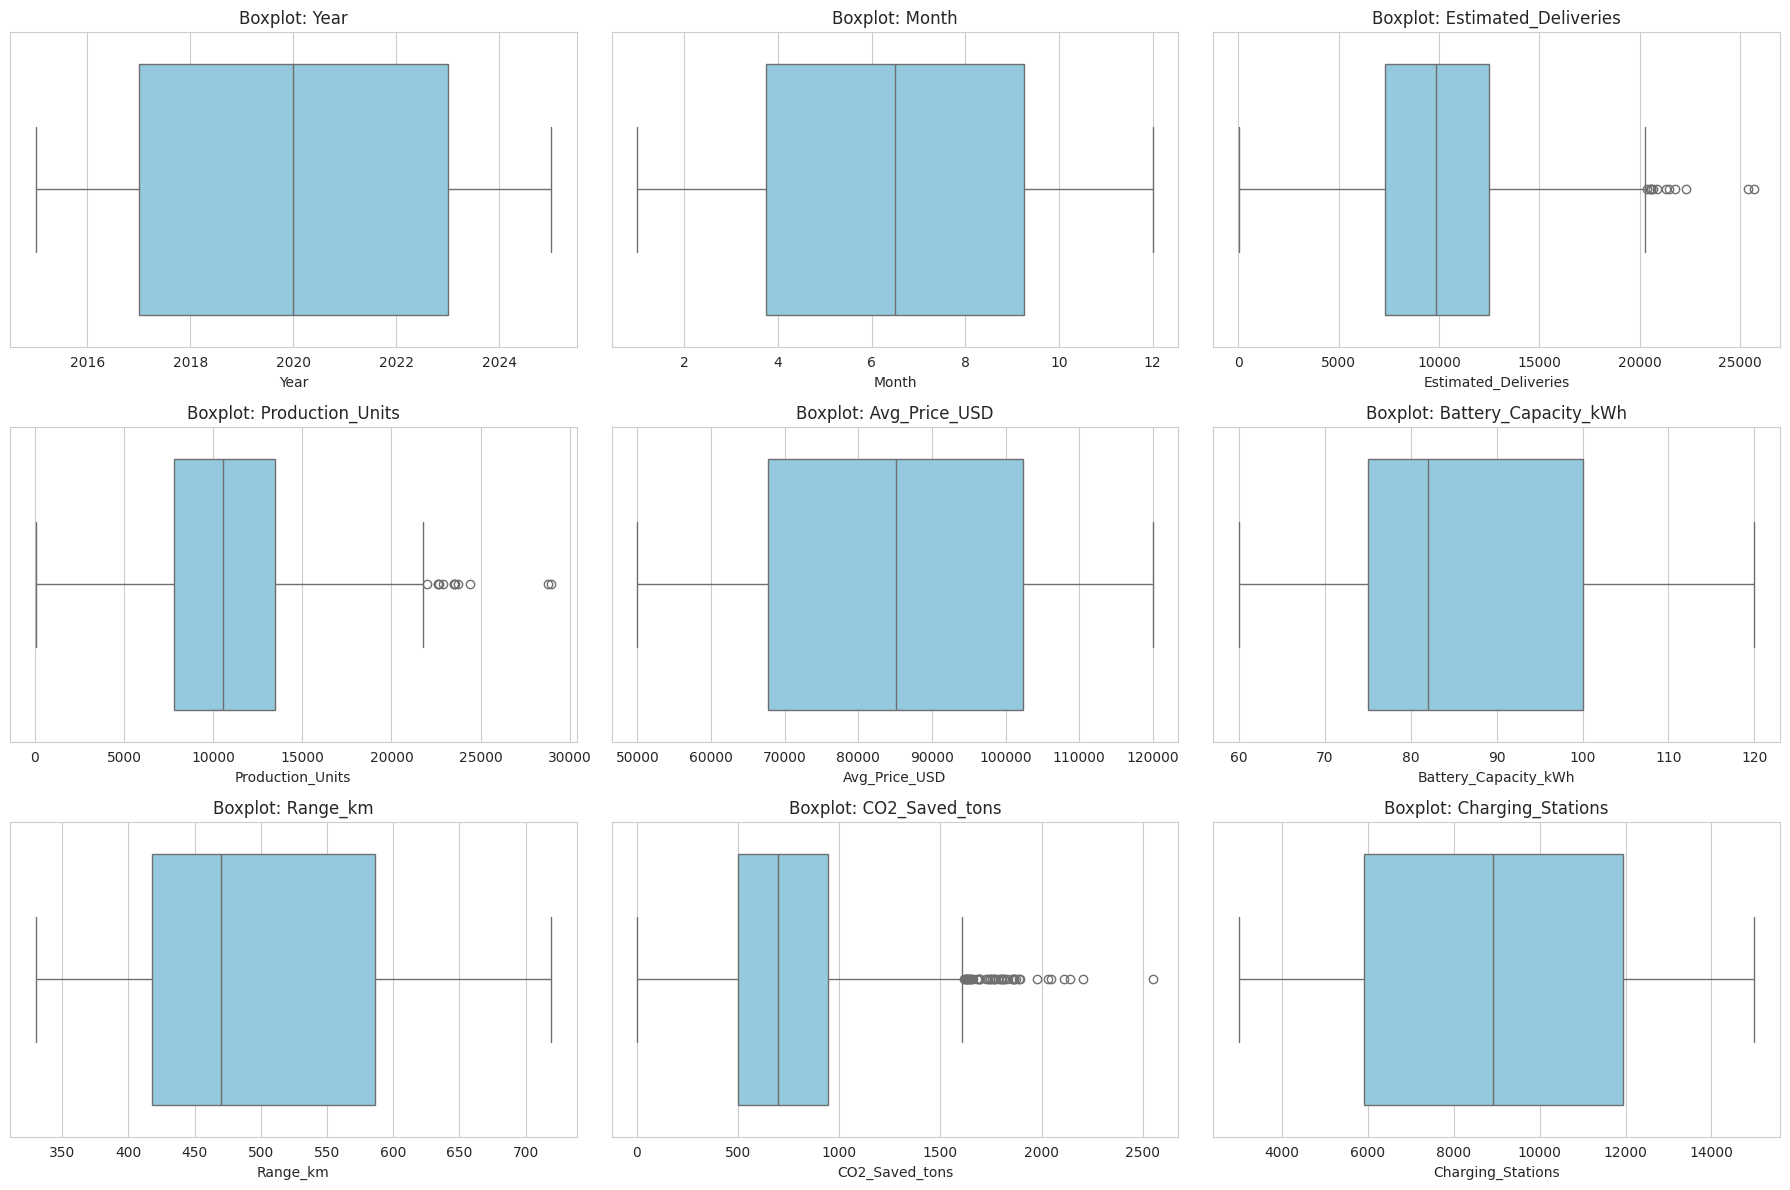

In [58]:
# Boxplots
plt.figure(figsize=(18, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)+2)//3, 3, i)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

In [59]:
# EDA

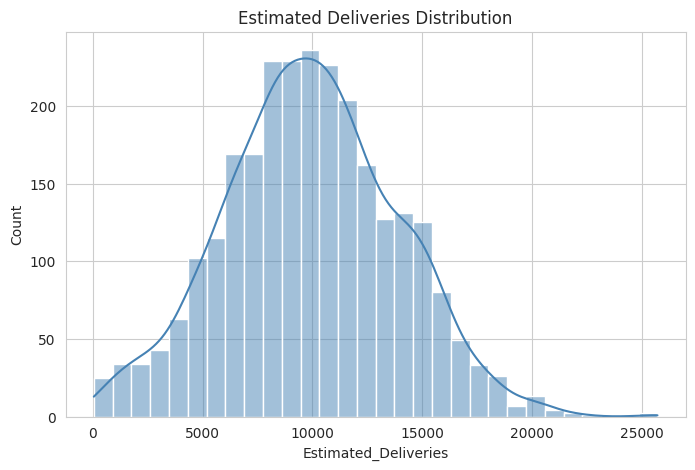

In [60]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(df["Estimated_Deliveries"], kde=True, bins=30, color="steelblue")
plt.title("Estimated Deliveries Distribution")
plt.show()

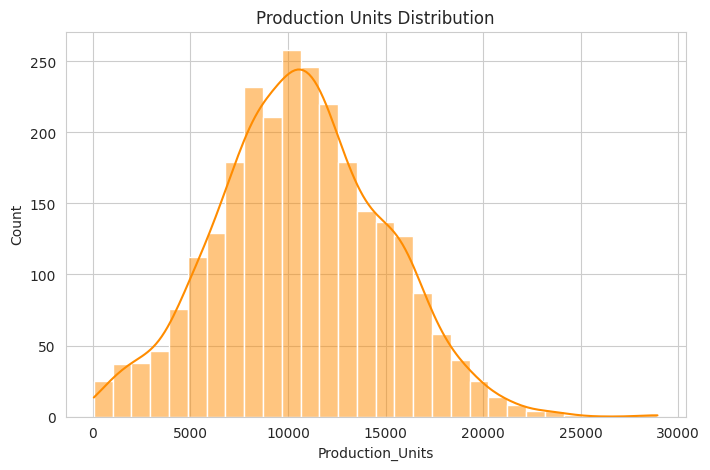

In [61]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Production_Units"], kde=True, bins=30, color="darkorange")
plt.title("Production Units Distribution")
plt.show()

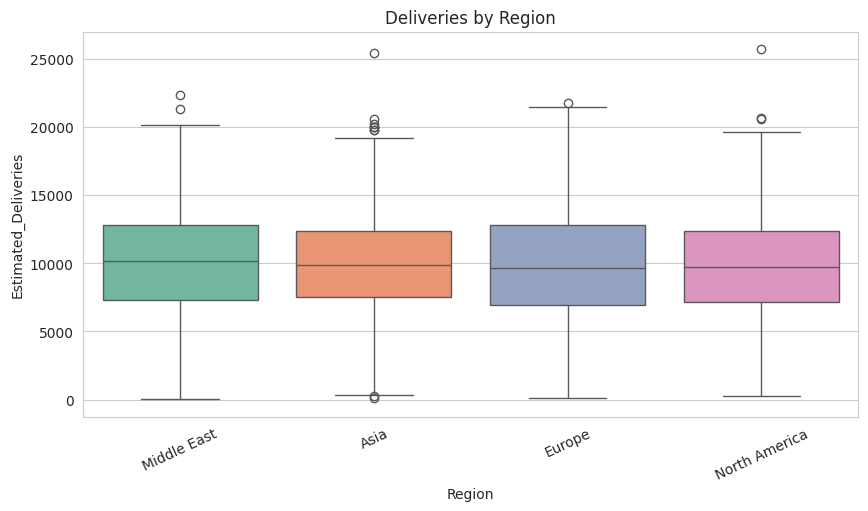

In [62]:
plt.figure(figsize=(10, 5))
region_order = df.groupby("Region")["Estimated_Deliveries"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="Region", y="Estimated_Deliveries", order=region_order, palette="Set2")
plt.xticks(rotation=25)
plt.title("Deliveries by Region")
plt.show()

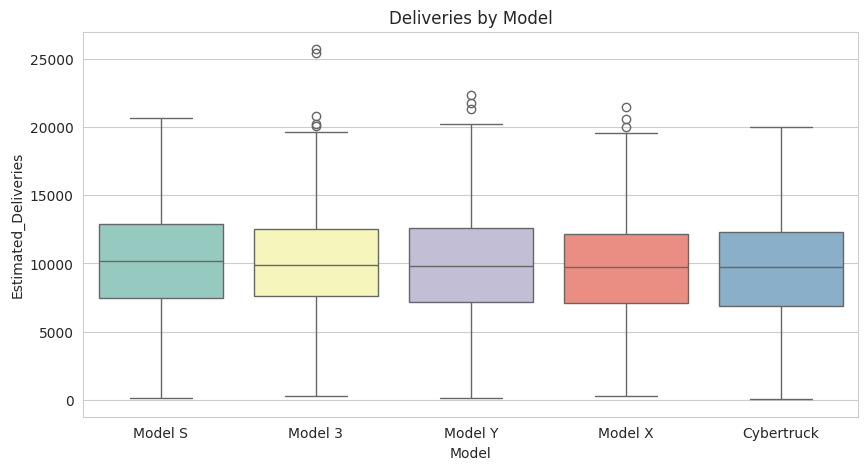

In [63]:
plt.figure(figsize=(10, 5))
model_order = df.groupby("Model")["Estimated_Deliveries"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="Model", y="Estimated_Deliveries", order=model_order, palette="Set3")
plt.title("Deliveries by Model")
plt.show()

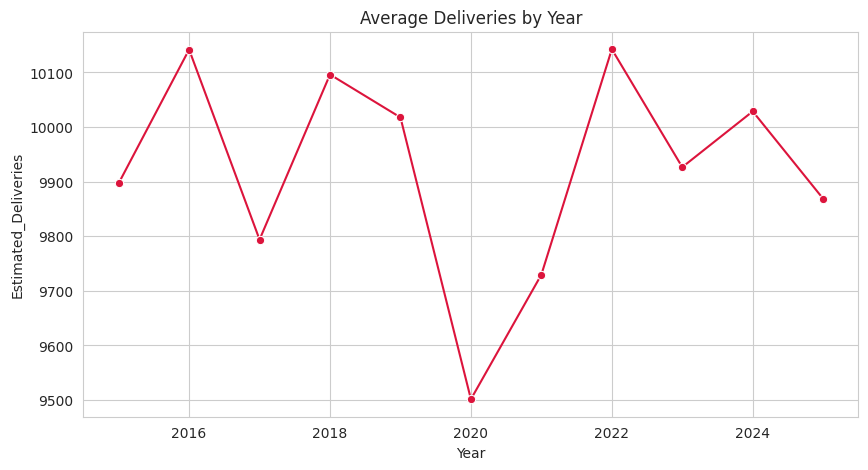

In [64]:
plt.figure(figsize=(10, 5))
yearly = df.groupby("Year")["Estimated_Deliveries"].mean().reset_index()
sns.lineplot(data=yearly, x="Year", y="Estimated_Deliveries", marker="o", color="crimson")
plt.title("Average Deliveries by Year")
plt.show()

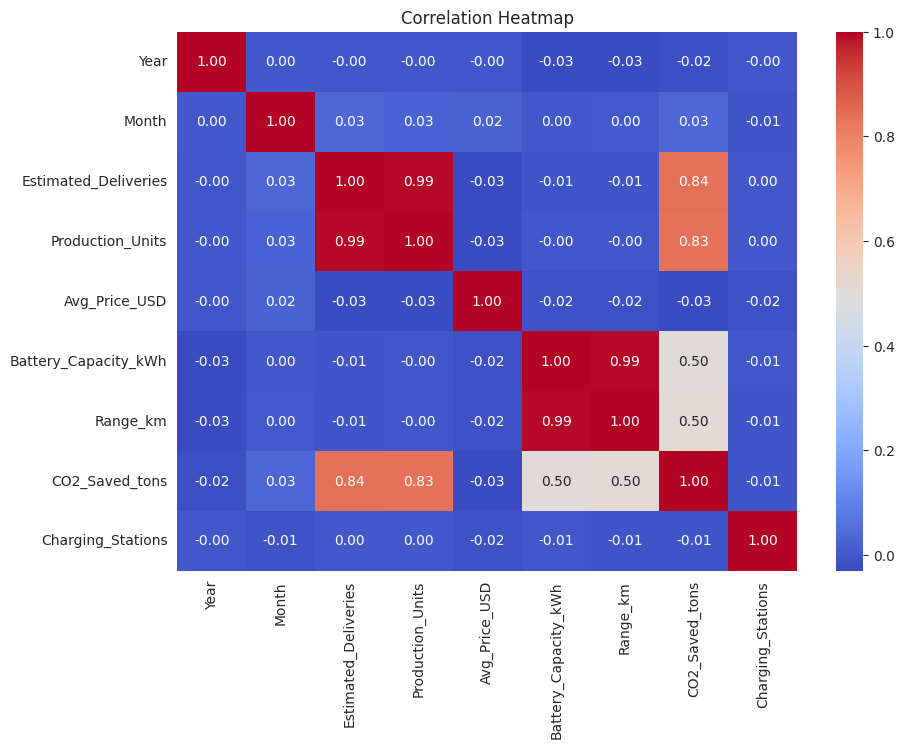

In [65]:
plt.figure(figsize=(10, 7))
corr_data = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

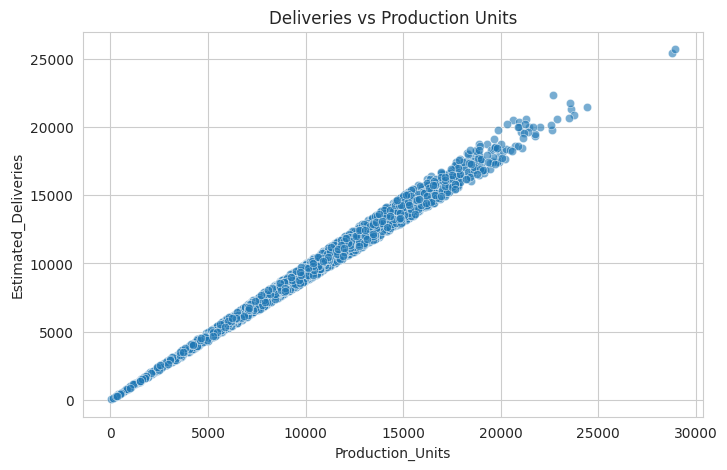

In [66]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries", alpha=0.6)
plt.title("Deliveries vs Production Units")
plt.show()

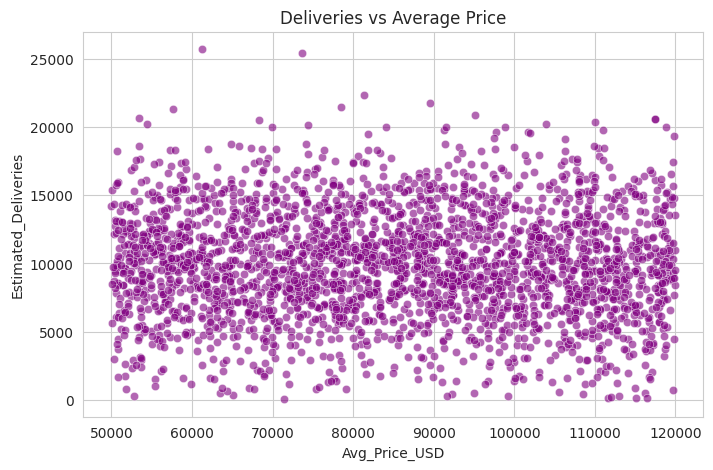

In [67]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Avg_Price_USD", y="Estimated_Deliveries", alpha=0.6, color="purple")
plt.title("Deliveries vs Average Price")
plt.show()

In [68]:
#Feature Engineering

In [69]:
# Build Date and sort chronologically
df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
df = df.sort_values("Date").reset_index(drop=True)


df["Price_per_km"] = df["Avg_Price_USD"] / df["Range_km"].replace(0, np.nan)

# Lag/rolling from past target values are valid for forecasting if shifted
df["Lag_1"] = df["Estimated_Deliveries"].shift(1)
df["Lag_3"] = df["Estimated_Deliveries"].shift(3)
df["Lag_6"] = df["Estimated_Deliveries"].shift(6)

df["Rolling_Mean_3"] = df["Estimated_Deliveries"].shift(1).rolling(window=3).mean()
df["Rolling_Std_3"] = df["Estimated_Deliveries"].shift(1).rolling(window=3).std()

# Cyclical month encoding
df["Month_Sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_Cos"] = np.cos(2 * np.pi * df["Month"] / 12)

# Clean up
df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("Shape after leak-free feature engineering:", df.shape)
df.head()

Shape after leak-free feature engineering: (2634, 21)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Charging_Stations,Date,Price_per_km,Lag_1,Lag_3,Lag_6,Rolling_Mean_3,Rolling_Std_3,Month_Sin,Month_Cos
0,2015,1,North America,Model S,11986,13302,91906.09,82,457,821.64,...,4871,2015-01-01,201.107418,2161.0,6367.0,12446.0,5774.333333,3356.475731,0.5,0.866025
1,2015,1,Europe,Model X,8833,8878,113652.43,82,461,610.80,...,10950,2015-01-01,246.534555,11986.0,8795.0,11446.0,7647.333333,5012.036545,0.5,0.866025
2,2015,1,North America,Model 3,9446,9528,110632.33,75,435,616.35,...,11496,2015-01-01,254.327195,8833.0,2161.0,8803.0,7660.000000,5016.433295,0.5,0.866025
3,2015,1,Europe,Model S,4350,4736,53251.53,82,475,309.94,...,5046,2015-01-01,112.108484,9446.0,11986.0,6367.0,10088.333333,1671.764437,0.5,0.866025
4,2015,1,North America,Model X,8122,8343,62838.32,75,423,515.34,...,9297,2015-01-01,148.553948,4350.0,8833.0,8795.0,7543.000000,2782.153662,0.5,0.866025


In [70]:
# ENCODING & SCALING

In [71]:
target = "Estimated_Deliveries"

categorical_features = ["Region", "Model", "Source_Type"]
numerical_features = [c for c in df.columns if c not in categorical_features + [target, "Date"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [72]:
#  ML PIPELINE

In [73]:
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

print("Pipeline created successfully.")

Pipeline created successfully.


In [74]:
#Regrssion Modeling


In [75]:
X = df.drop(columns=[target, "Date"])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Lasso Regression": Lasso(alpha=0.001, random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

comparison_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"]).sort_values("R2", ascending=False)
comparison_df

,Model,MAE,RMSE,R2
2,Lasso Regression,325.088088,405.231649,0.989171
0,Linear Regression,325.088446,405.232511,0.989171
1,Ridge Regression,325.133500,405.356880,0.989164
3,Random Forest,329.649393,429.216390,0.987851


In [76]:
best_model_name = comparison_df.iloc[0]["Model"]
print("Best model based on R2:", best_model_name)

Best model based on R2: Lasso Regression


In [77]:
# CROSS VALIDATION

In [80]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

tuned_pred = grid.best_estimator_.predict(X_test)
print("Tuned Test R2:", r2_score(y_test, tuned_pred))
print("Tuned Test RMSE:", np.sqrt(mean_squared_error(y_test, tuned_pred)))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV Score: 0.9850403393639023
Tuned Test R2: 0.9877396872534469
Tuned Test RMSE: 431.1772042797628


In [ ]:
# HYPERPARAMETER TUNNING

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
# Compare tuned vs untuned RF on test set
untuned_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_estimators=200))
])

untuned_rf.fit(X_train, y_train)
untuned_pred = untuned_rf.predict(X_test)

tuned_pred = grid.best_estimator_.predict(X_test)

comparison_tuning = pd.DataFrame({
    "Model": ["Untuned RF", "Tuned RF"],
    "MAE": [
        mean_absolute_error(y_test, untuned_pred),
        mean_absolute_error(y_test, tuned_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, untuned_pred)),
        np.sqrt(mean_squared_error(y_test, tuned_pred))
    ],
    "R2": [
        r2_score(y_test, untuned_pred),
        r2_score(y_test, tuned_pred)
    ]
})

comparison_tuning

In [ ]:
#time Series Analysis
# Monthly aggregate deliveries
ts = df.groupby("Date", as_index=True)["Estimated_Deliveries"].sum().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(ts.index, ts.values, color="teal")
plt.title("Monthly Tesla Estimated Deliveries")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.show()

In [ ]:
# ADF test
adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for k, v in adf_result[4].items():
    print(f"  {k}: {v}")

In [ ]:
if adf_result[1] < 0.05:
    print("Series appears stationary (reject H0).")
else:
    print("Series appears non-stationary (fail to reject H0).")

In [ ]:
# Lag visualization
ts_lag1 = ts.shift(1)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=ts_lag1, y=ts, alpha=0.7)
plt.title("Lag Feature Visualization (t-1 vs t)")
plt.xlabel("Lag_1 Deliveries")
plt.ylabel("Current Deliveries")
plt.show()

In [ ]:
# Rolling mean and std visualization
roll_mean = ts.rolling(window=3).mean()
roll_std = ts.rolling(window=3).std()

plt.figure(figsize=(12, 5))
plt.plot(ts, label="Original", color="blue")
plt.plot(roll_mean, label="Rolling Mean (3)", color="red")
plt.plot(roll_std, label="Rolling Std (3)", color="green")
plt.title("Rolling Mean and Rolling Standard Deviation")
plt.legend()
plt.show()

In [ ]:
# Rolling mean and std visualization
roll_mean = ts.rolling(window=3).mean()
roll_std = ts.rolling(window=3).std()

plt.figure(figsize=(12, 5))
plt.plot(ts, label="Original", color="blue")
plt.plot(roll_mean, label="Rolling Mean (3)", color="red")
plt.plot(roll_std, label="Rolling Std (3)", color="green")
plt.title("Rolling Mean and Rolling Standard Deviation")
plt.legend()
plt.show()

In [ ]:
#Chronological Split


In [ ]:
target = "Estimated_Deliveries"

categorical_features = ["Region", "Model", "Source_Type"]
numerical_features = [c for c in df.columns if c not in categorical_features + [target, "Date"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X = df.drop(columns=[target, "Date"])
y = df[target]

# Chronological split (not random)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Lasso Regression": Lasso(alpha=0.001, random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    # Optional: train score check for overfitting
    train_pred = pipe.predict(X_train)
    train_r2 = r2_score(y_train, train_pred)

    results.append([name, mae, rmse, r2, train_r2])

comparison_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "Test_R2", "Train_R2"])
comparison_df = comparison_df.sort_values("Test_R2", ascending=False)
comparison_df

In [ ]:
#Arima

In [ ]:
# Basic ARIMA model (can be tuned further)
arima_model = ARIMA(train_ts, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Forecast next 12 months
forecast_steps = 12
forecast = arima_fit.forecast(steps=forecast_steps)

# Align forecast index from last observed month
forecast_index = pd.date_range(
    start=ts.index.max() + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq="MS"
)
forecast = pd.Series(forecast.values, index=forecast_index)

In [ ]:
# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(train_ts, label="Train")
plt.plot(test_ts, label="Test", color="orange")
plt.plot(forecast, label="Forecast (Next 12 Months)", color="red")
plt.title("ARIMA Forecast: Actual vs Forecast")
plt.legend()
plt.show()

In [ ]:
# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(train_ts, label="Train")
plt.plot(test_ts, label="Test", color="orange")
plt.plot(forecast, label="Forecast (Next 12 Months)", color="red")
plt.title("ARIMA Forecast: Actual vs Forecast")
plt.legend()
plt.show()

In [ ]:
# Evaluate against first 12 points of test set if available
eval_len = min(len(test_ts), 12)
actual_eval = test_ts.iloc[:eval_len]
pred_eval = forecast.iloc[:eval_len]

mae_arima = mean_absolute_error(actual_eval, pred_eval)
rmse_arima = np.sqrt(mean_squared_error(actual_eval, pred_eval))
mape_arima = np.mean(np.abs((actual_eval - pred_eval) / actual_eval)) * 100

print("ARIMA Evaluation")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)